# Egyptian National ID Detection Using YOLO Models

## Project Overview

This notebook compares several YOLO object detection models trained on the Egyptian National ID dataset.

The purpose of this analysis is to answer the following questions:

### 1. Does data augmentation improve performance?
To answer this question, we compare:

- YOLO11s without augmentation
- YOLO11s with augmentation

### 2. Which YOLO architecture performs best?
To answer this question, we compare:

- YOLOv5s + augmentation
- YOLOv8s + augmentation
- YOLO11s + augmentation

---

## Evaluation Metrics

The following metrics are used:

### Precision
Measures how many detected objects are actually correct.

### Recall
Measures how many real objects were successfully detected.

### mAP@50
Measures detection accuracy using an IoU threshold of 50%.

### mAP@50-95
A stricter metric used in most research papers. It averages performance across multiple IoU thresholds.

### Model Size
Represents the storage size of the trained model and is important when deploying to embedded systems or mobile devices.

---

## Expected Outcome

At the end of this notebook we will:

1. Extract the results of all trained models.
2. Create a comparison table.
3. Analyze the effect of data augmentation.
4. Compare different YOLO architectures.
5. Determine the best model for Egyptian National ID field detection.


# Step 1: Import Required Libraries

Before reading the training results, we need to import several Python libraries.

### pandas
Used to read and process CSV files.

### os
Used to access folders and files on the computer.

### matplotlib
Used to create charts and visualizations.


In [50]:
# Import required libraries

import pandas as pd
import os
import matplotlib.pyplot as plt

# Step 2: Define Dataset Location

All trained YOLO models are stored inside the `detect` folder.

Update the path below if your models are stored in another location.

The folder structure should look like:

```text
detect/
├── yolo11s_withoutaug
├── yolo11s_aug
├── yolov5s_aug
└── yolov8s_aug
```


In [51]:
# Root directory containing all trained models

ROOT = r"C:\Users\HP\Downloads\Trained_Models_Parameters\detect"

# List of all models included in the comparison

all_models = [
    "yolo11s_withoutaug",
    "yolov8s_withoutaug",
    "yolov5s_withoutaug",
    "yolo11s_aug",
    "yolov5s_aug",
    "yolov8s_aug"
]

# Step 3: Read Final Training Results

Every YOLO training run creates a file called:

```text
results.csv
```

This file contains:

- Training loss
- Validation loss
- Precision
- Recall
- mAP50
- mAP50-95

for every training epoch.

The last row corresponds to the final training epoch and represents the final model performance.


In [52]:
# Empty list that will store results from all models

results = []

# Loop through every trained model

for model in all_models:

    # Path to results.csv file
    csv_path = os.path.join(ROOT, model, "results.csv")

    # Skip model if file does not exist
    if not os.path.exists(csv_path):
        print(f"Missing: {csv_path}")
        continue

    # Read training results
    df = pd.read_csv(csv_path)

    # Extract final epoch
    last = df.iloc[-1]

    # Total training time from last epoch
    training_time_sec = last["time"]

    # Convert to minutes
    training_time_min = training_time_sec / 60

    # Path to trained model
    weight_path = os.path.join(
        ROOT,
        model,
        "weights",
        "best.pt"
    )

    # Calculate model size
    size_mb = os.path.getsize(weight_path) / (1024 * 1024)

    # Store all metrics
    results.append({
        "Model": model,
        "Precision": round(last["metrics/precision(B)"], 3),
        "Recall": round(last["metrics/recall(B)"], 3),
        "mAP50": round(last["metrics/mAP50(B)"], 3),
        "mAP50-95": round(last["metrics/mAP50-95(B)"], 3),
        "Training Time (min)": round(training_time_min, 2),
        "Model Size (MB)": round(size_mb, 2)
    })

# Convert collected results into a table
comparison_df = pd.DataFrame(results)

comparison_df

,Model,Precision,Recall,mAP50,mAP50-95,Training Time (min),Model Size (MB)
0,yolo11s_withoutaug,0.903,0.912,0.947,0.619,7.13,18.30
1,yolov8s_withoutaug,0.942,0.884,0.941,0.631,6.73,21.48
2,yolov5s_withoutaug,0.940,0.838,0.936,0.592,6.79,17.67
3,yolo11s_aug,0.895,0.767,0.870,0.529,7.14,18.30
4,yolov5s_aug,0.918,0.821,0.898,0.557,6.72,17.67
5,yolov8s_aug,0.888,0.688,0.779,0.476,6.82,21.48


# Step 4: Save Comparison Table

The table generated above can be saved as a CSV file.

This allows the results to be used later in reports, presentations, or further analysis.


In [53]:
comparison_df.to_csv(
    os.path.join(ROOT, "comparison_results.csv"),
    index=False
)

print("Comparison table saved successfully.")

Comparison table saved successfully.


# Step 5: Create a Reusable Plot Function

Instead of writing the same plotting code many times, we create one function.

A function is simply a reusable block of code.

This function will:

1. Read training results.
2. Extract the selected metric.
3. Plot the metric against training epochs.
4. Compare multiple models on the same figure.


In [54]:
def compare_models(metric,
                   models,
                   title,
                   ylabel):

    # Create a new figure
    plt.figure(figsize=(10,6))

    # Plot selected metric for every model
    for model in models:

        df = pd.read_csv(
            os.path.join(ROOT, model, "results.csv")
        )

        plt.plot(
            df["epoch"],
            df[metric],
            linewidth=2,
            marker='o',
            markersize=4,
            label=model
        )

    # Figure formatting
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


# Part 1: Effect of Data Augmentation

The purpose of this section is to determine whether data augmentation improves performance.

The following models are compared:

- YOLO11s without augmentation
- YOLO11s with augmentation

If the augmented model consistently achieves higher values, augmentation is beneficial.


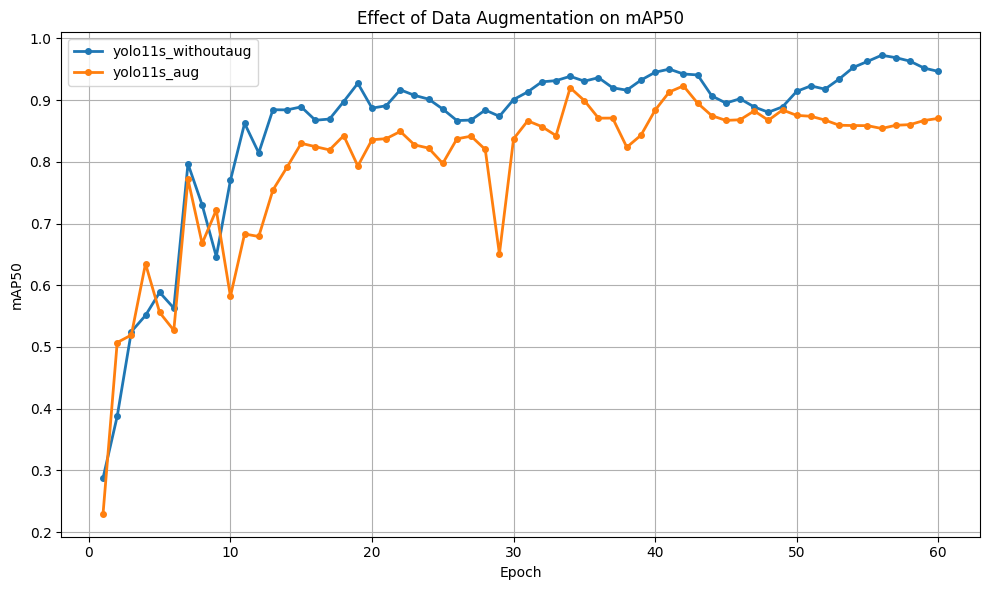

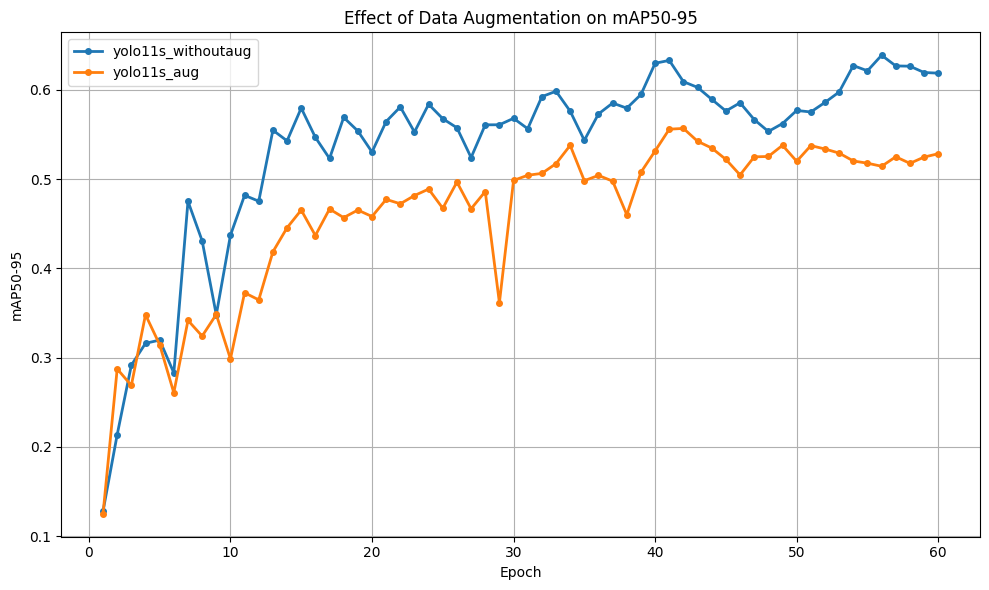

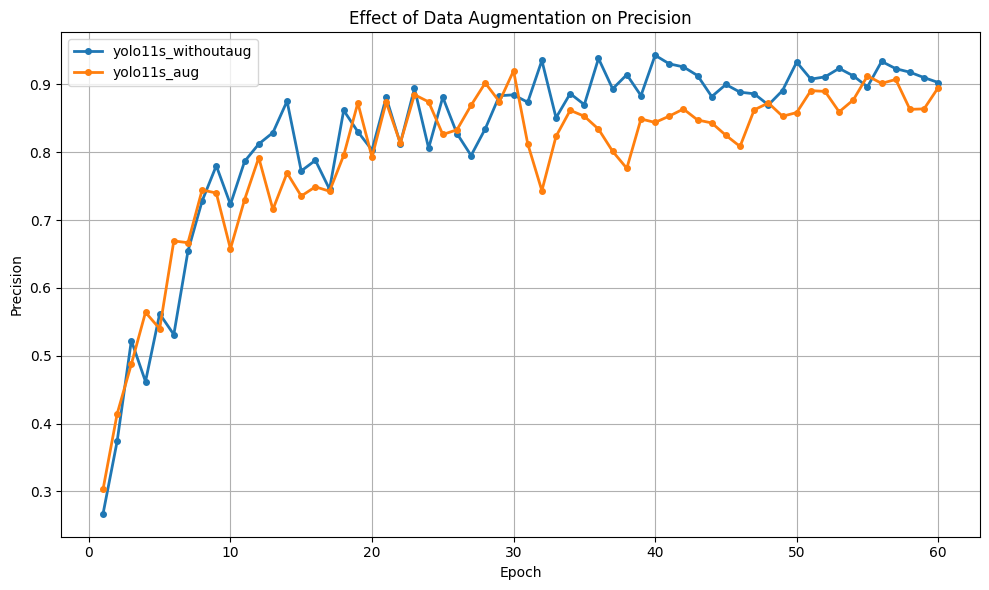

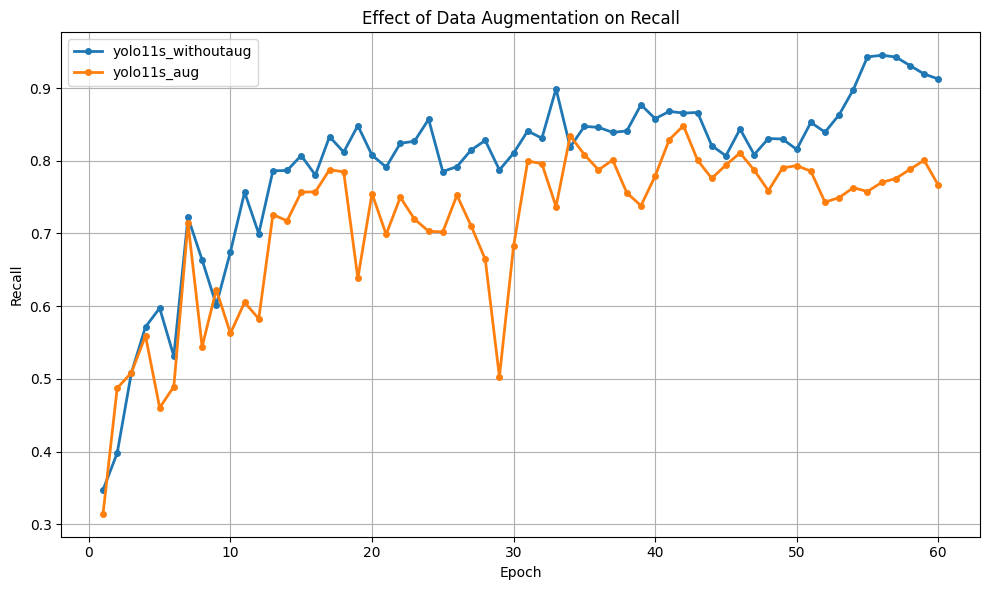

In [55]:
aug_models = [
    "yolo11s_withoutaug",
    "yolo11s_aug"
]

compare_models(
    "metrics/mAP50(B)",
    aug_models,
    "Effect of Data Augmentation on mAP50",
    "mAP50"
)

compare_models(
    "metrics/mAP50-95(B)",
    aug_models,
    "Effect of Data Augmentation on mAP50-95",
    "mAP50-95"
)

compare_models(
    "metrics/precision(B)",
    aug_models,
    "Effect of Data Augmentation on Precision",
    "Precision"
)

compare_models(
    "metrics/recall(B)",
    aug_models,
    "Effect of Data Augmentation on Recall",
    "Recall"
)

# Part 2: YOLO Architecture Comparison

The purpose of this section is to compare different YOLO generations.

The following models are compared:

- YOLOv5s
- YOLOv8s
- YOLO11s

All models use augmentation to ensure a fair comparison.


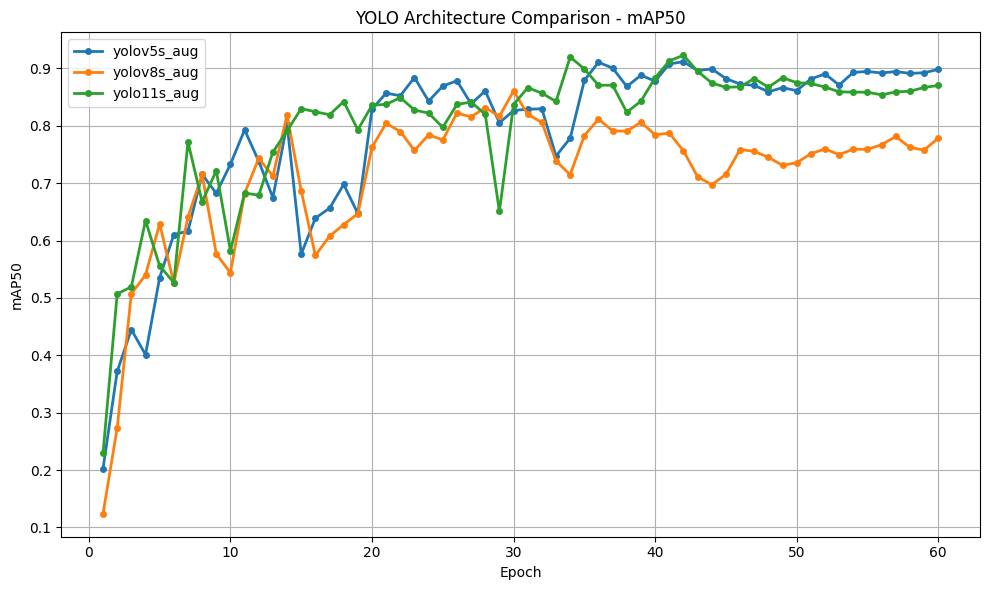

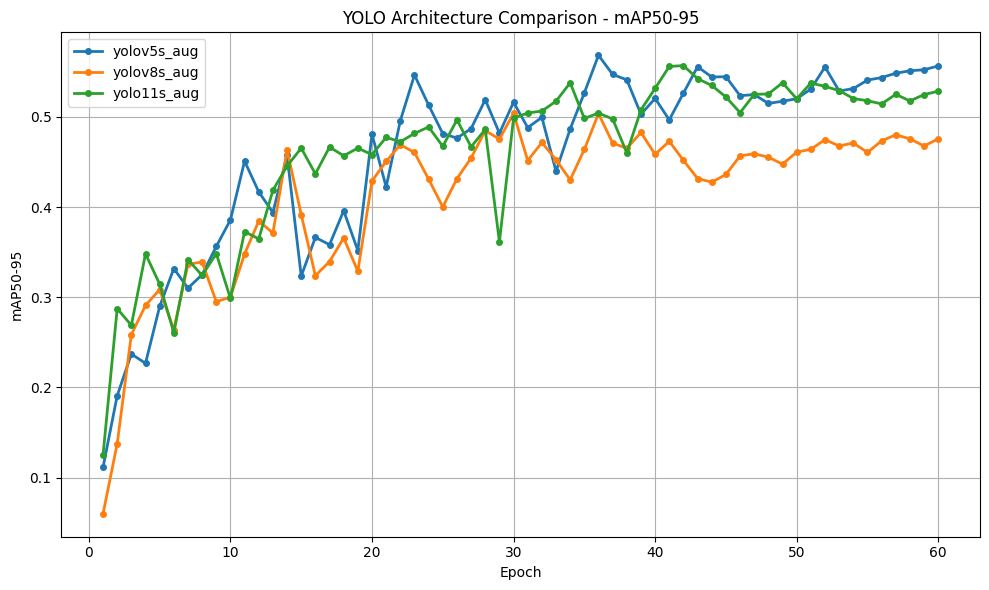

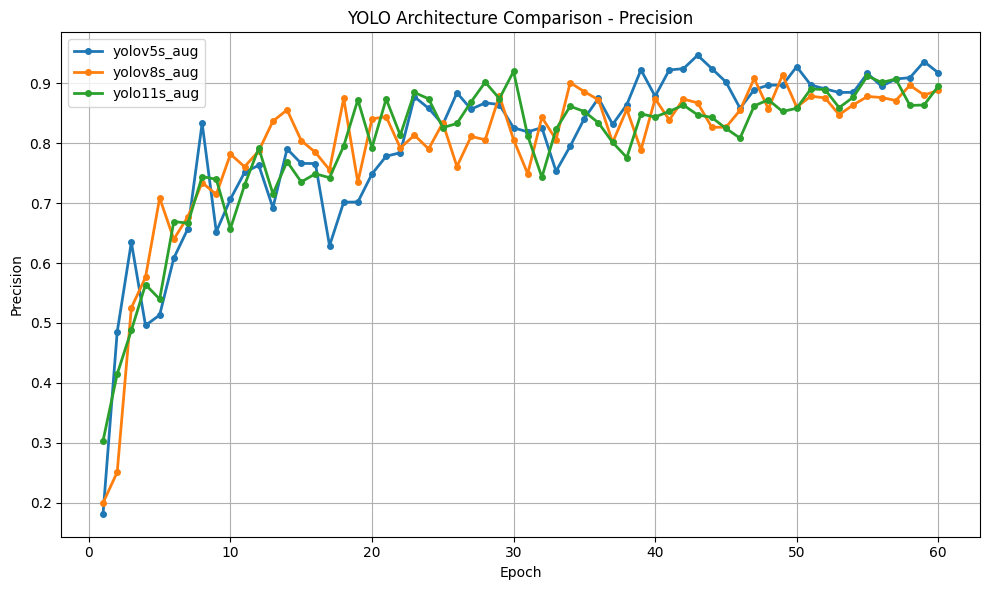

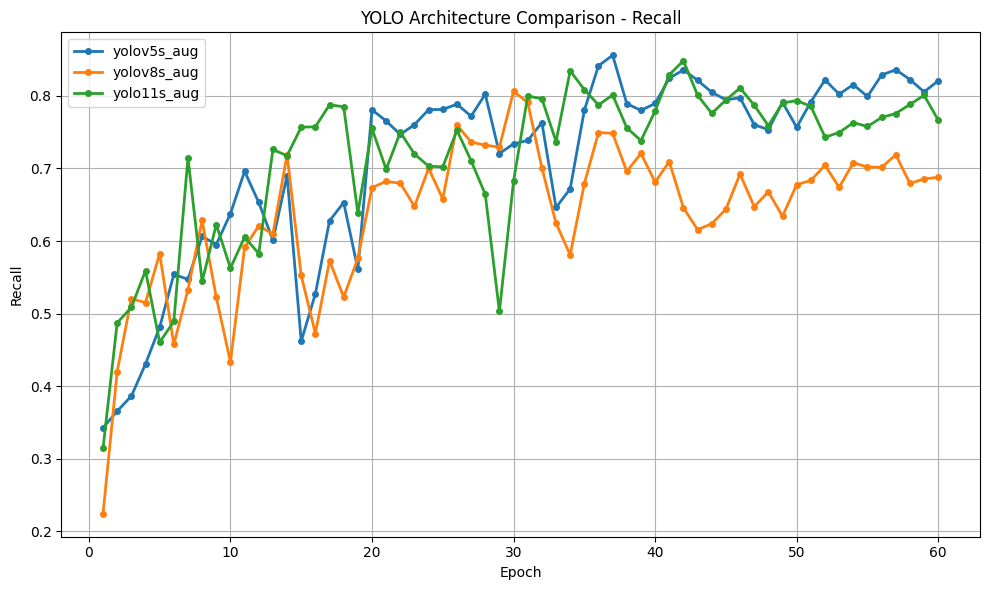

In [56]:
arch_models = [
    "yolov5s_aug",
    "yolov8s_aug",
    "yolo11s_aug"
]

compare_models(
    "metrics/mAP50(B)",
    arch_models,
    "YOLO Architecture Comparison - mAP50",
    "mAP50"
)

compare_models(
    "metrics/mAP50-95(B)",
    arch_models,
    "YOLO Architecture Comparison - mAP50-95",
    "mAP50-95"
)

compare_models(
    "metrics/precision(B)",
    arch_models,
    "YOLO Architecture Comparison - Precision",
    "Precision"
)

compare_models(
    "metrics/recall(B)",
    arch_models,
    "YOLO Architecture Comparison - Recall",
    "Recall"
)

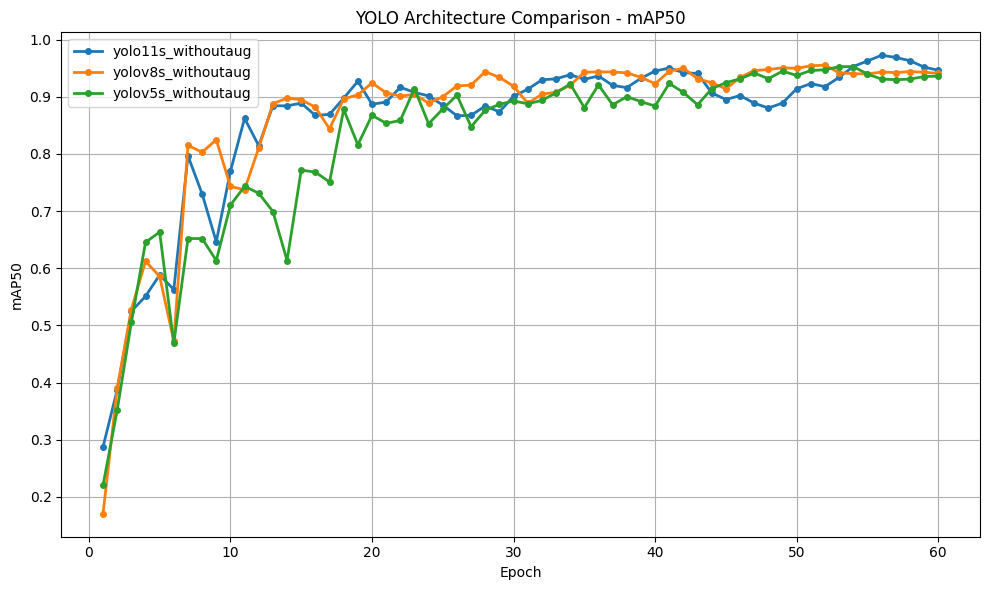

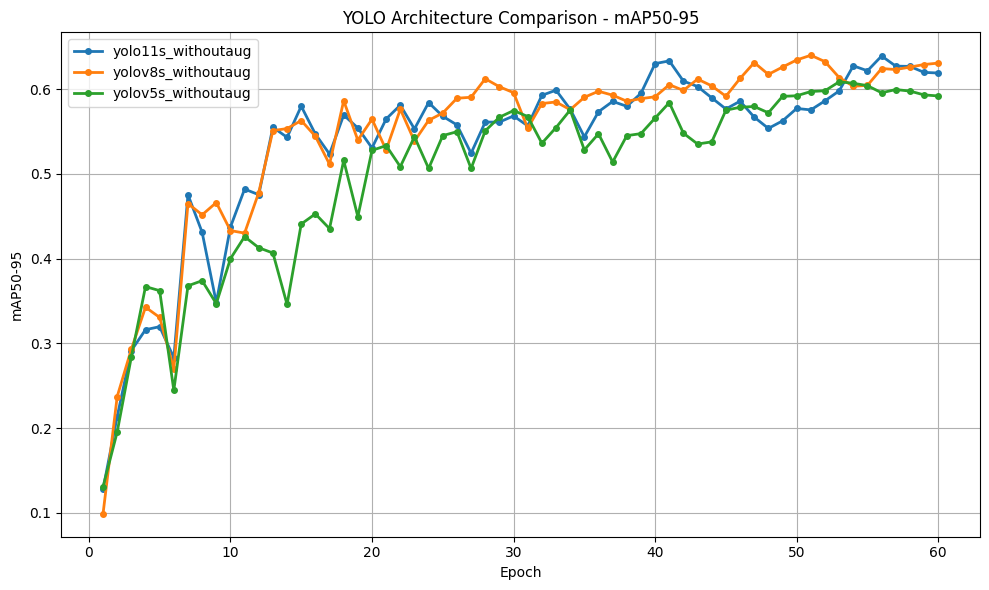

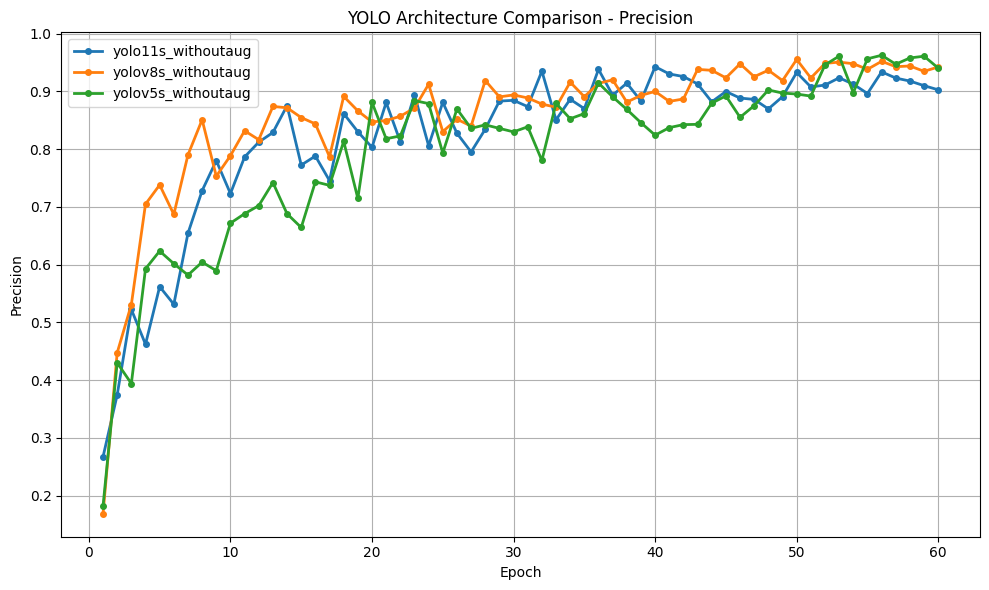

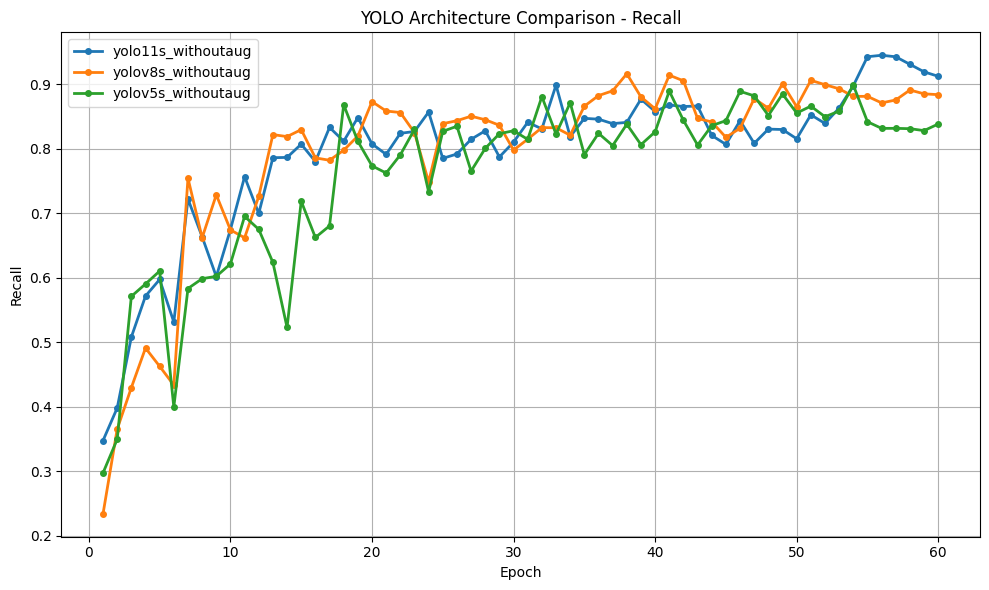

In [57]:
arch_models = [
    "yolo11s_withoutaug",
    "yolov8s_withoutaug",
    "yolov5s_withoutaug"
]

compare_models(
    "metrics/mAP50(B)",
    arch_models,
    "YOLO Architecture Comparison - mAP50",
    "mAP50"
)

compare_models(
    "metrics/mAP50-95(B)",
    arch_models,
    "YOLO Architecture Comparison - mAP50-95",
    "mAP50-95"
)

compare_models(
    "metrics/precision(B)",
    arch_models,
    "YOLO Architecture Comparison - Precision",
    "Precision"
)

compare_models(
    "metrics/recall(B)",
    arch_models,
    "YOLO Architecture Comparison - Recall",
    "Recall"
)

# Final Comparison Charts

The following charts compare the final performance values of all trained models.

Unlike previous figures that showed performance across epochs, these charts compare the final results only.


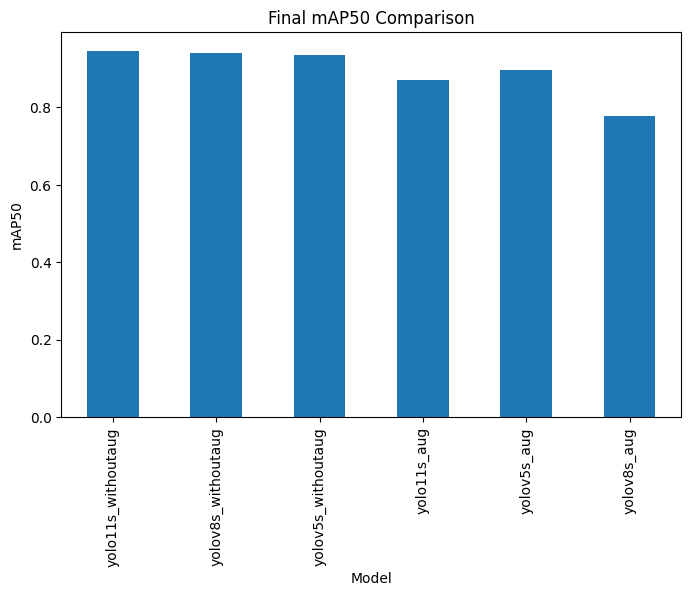

In [58]:
comparison_df.plot(
    x="Model",
    y="mAP50",
    kind="bar",
    figsize=(8,5),
    legend=False,
    title="Final mAP50 Comparison"
)

plt.ylabel("mAP50")
plt.show()

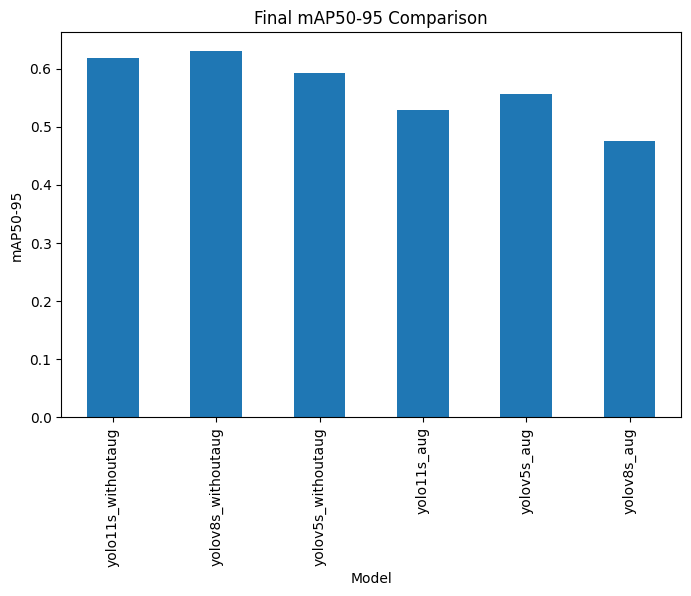

In [59]:
comparison_df.plot(
    x="Model",
    y="mAP50-95",
    kind="bar",
    figsize=(8,5),
    legend=False,
    title="Final mAP50-95 Comparison"
)

plt.ylabel("mAP50-95")
plt.show()

# Model Size Comparison

The final comparison focuses on model size.

This helps evaluate the trade-off between:

* Accuracy
* Memory requirements
* Deployment feasibility

for real-world applications.


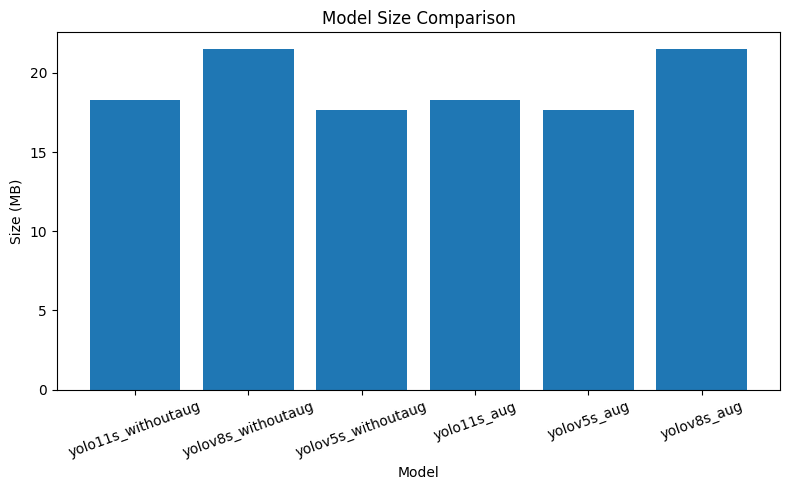

In [60]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Model Size (MB)"]
)

plt.title("Model Size Comparison")
plt.ylabel("Size (MB)")
plt.xlabel("Model")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

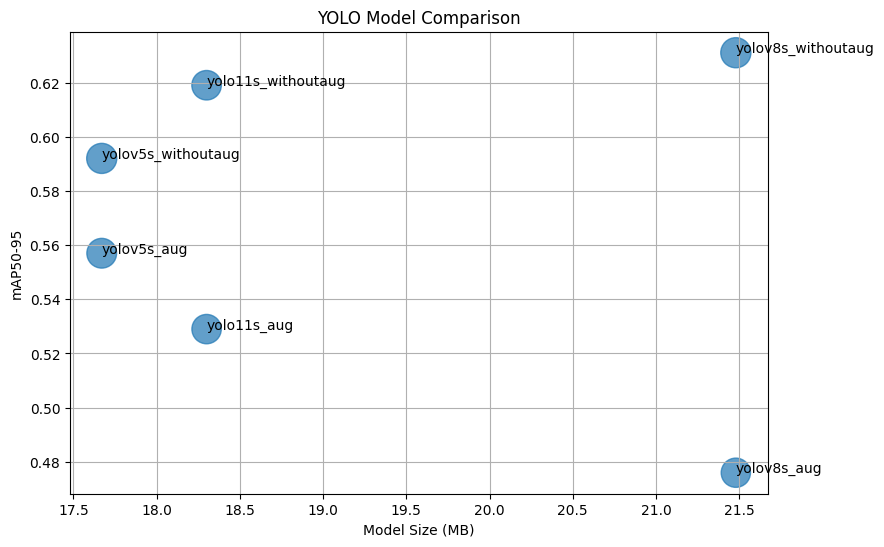

In [61]:
plt.figure(figsize=(9,6))

plt.scatter(
    comparison_df["Model Size (MB)"],
    comparison_df["mAP50-95"],
    s=comparison_df["Precision"]*500,
    alpha=0.7
)

for i, row in comparison_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["Model Size (MB)"],
         row["mAP50-95"])
    )

plt.xlabel("Model Size (MB)")
plt.ylabel("mAP50-95")

plt.title("YOLO Model Comparison")

plt.grid(True)

plt.show()

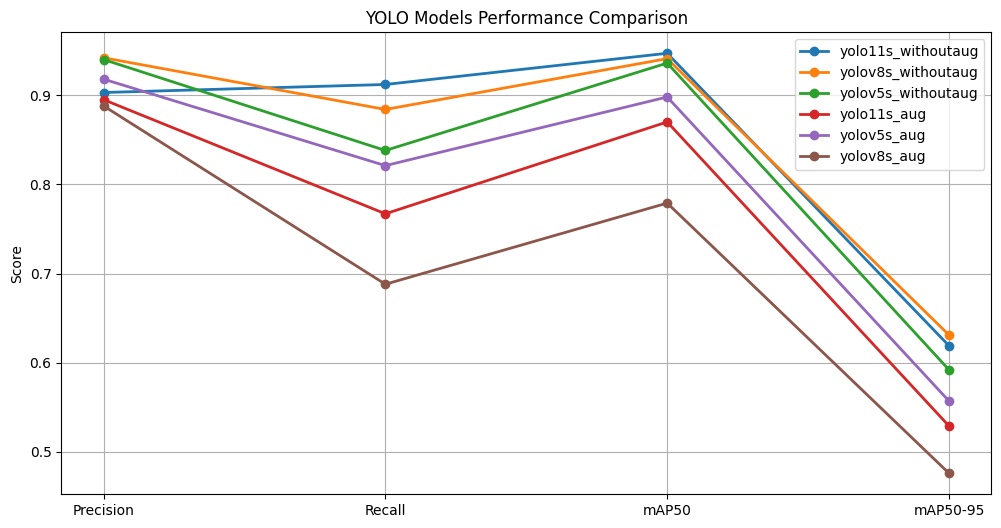

In [62]:
metrics = [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95"
]

plt.figure(figsize=(12,6))

for _, row in comparison_df.iterrows():

    plt.plot(
        metrics,
        [
            row["Precision"],
            row["Recall"],
            row["mAP50"],
            row["mAP50-95"]
        ],
        marker='o',
        linewidth=2,
        label=row["Model"]
    )

plt.title("YOLO Models Performance Comparison")
plt.ylabel("Score")

plt.grid(True)
plt.legend()

plt.show()

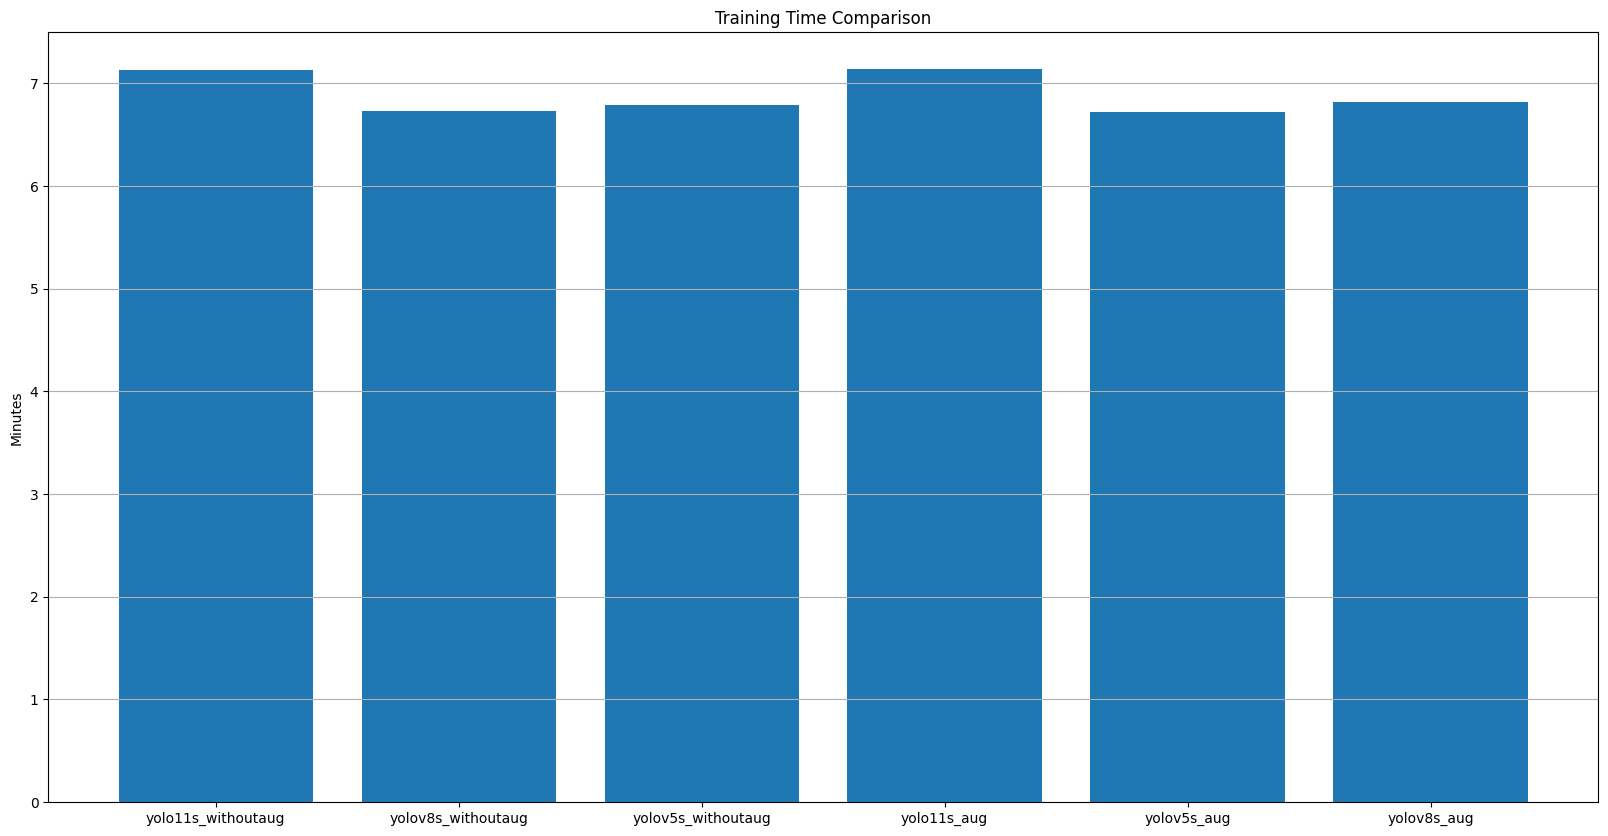

In [68]:
plt.figure(figsize=(20,10))

plt.bar(
    comparison_df["Model"],
    comparison_df["Training Time (min)"]
)

plt.title("Training Time Comparison")
plt.ylabel("Minutes")

plt.grid(axis='y')

plt.show()


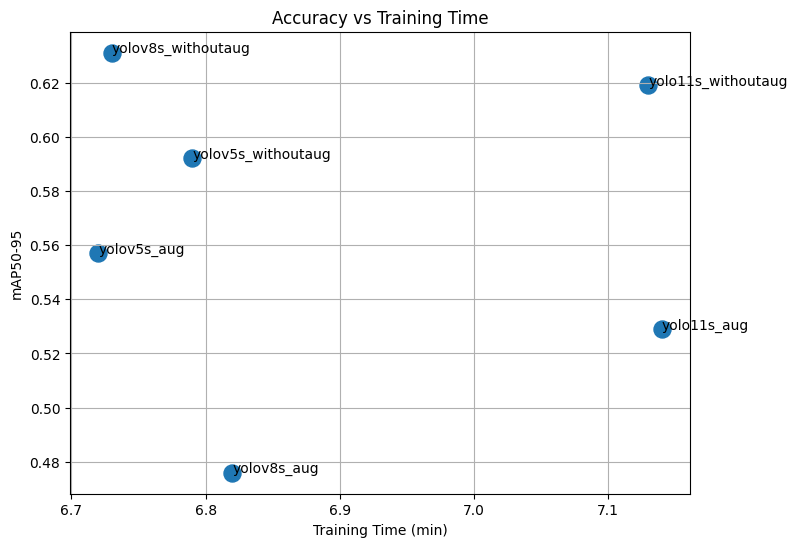

In [64]:
plt.figure(figsize=(8,6))

plt.scatter(
    comparison_df["Training Time (min)"],
    comparison_df["mAP50-95"],
    s=150
)

for _, row in comparison_df.iterrows():

    plt.annotate(
        row["Model"],
        (
            row["Training Time (min)"],
            row["mAP50-95"]
        )
    )

plt.xlabel("Training Time (min)")
plt.ylabel("mAP50-95")

plt.title("Accuracy vs Training Time")

plt.grid(True)

plt.show()

# Conclusions

After analyzing the generated figures and tables, We can answer the following questions:

### Augmentation Analysis
- Did augmentation improve mAP50?
- Did augmentation improve mAP50-95?
- Did augmentation improve Precision?
- Did augmentation improve Recall?

### Architecture Analysis
- Which model achieved the highest mAP50?
- Which model achieved the highest mAP50-95?
- Which model achieved the highest Precision?
- Which model achieved the highest Recall?

### Deployment Considerations
- Which model has the smallest size?
- Which model offers the best balance between performance and size?

We Use these observations to determine the most suitable model for Egyptian National ID field detection.
